In [2]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

## Ej c

In [ ]:
G = ctrl.TransferFunction([0.25], [0.003,0.0515,0.2,0.0])
G_pid = ctrl.TransferFunction([0.51,1.479,1.0723],[1,0])
L = G * G_pid
gm, pm, wg, wp = ctrl.margin(L)
gm_db = 20 * math.log10(gm)

print(f"Margen de Ganancia: {gm_db:.2f} dB en w = {wg:.2f} rad/s")
print(f"Margen de Fase: {pm:.2f} grados en w = {wp:.2f} rad/s")

Margen de Ganancia: inf dB en w = nan rad/s
Margen de Fase: 76.08 grados en w = 1.79 rad/s


/tmp/ipykernel_11055/1515091286.py:3: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ctrl.bode_plot([G, L], margins=True, label=['Original G(s)', 'Compensado L(s)'])


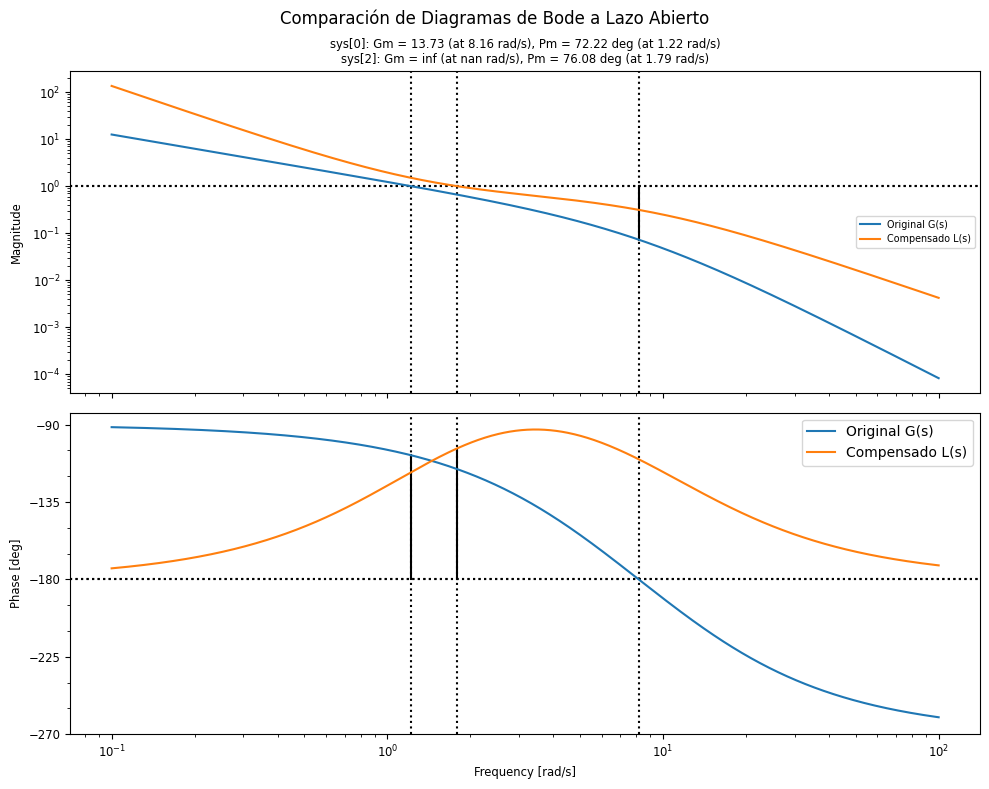

In [4]:
plt.figure(figsize=(10, 8))
# Trazamos ambos para compararlos (margins=True dibuja las líneas de los márgenes)
ctrl.bode_plot([G, L], margins=True, label=['Original G(s)', 'Compensado L(s)'])
plt.legend()
plt.suptitle('Comparación de Diagramas de Bode a Lazo Abierto')
plt.show()

## Ej d

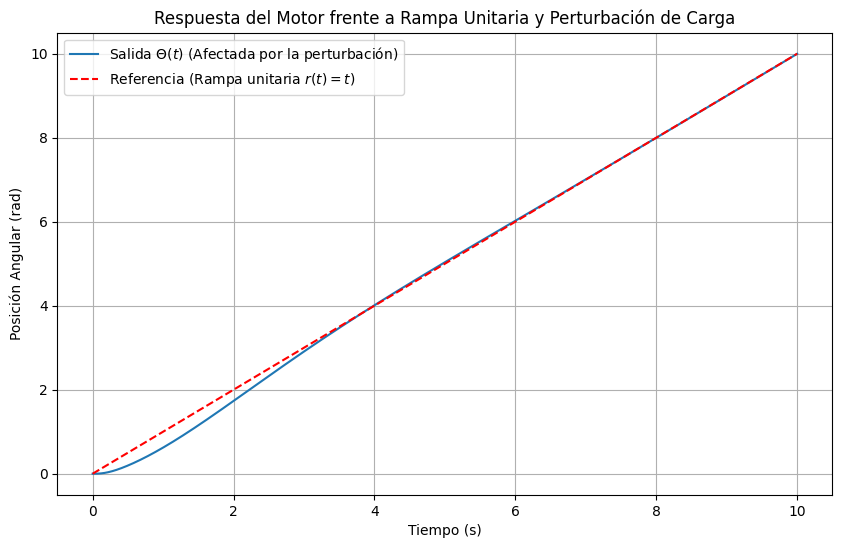

In [ ]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

G = ctrl.tf([0.25], [0.003, 0.0515, 0.2, 0])
C_pid = ctrl.tf([0.51, 1.479, 1.072], [1, 0])

T_ref = ctrl.feedback(C_pid * G, 1)

t = np.linspace(0, 10, 1000)
t,y_ref = ctrl.forced_response(T_ref, T=t,U=t)

plt.figure(figsize=(10, 6))

plt.plot(t,y_ref,label="Salida $\\Theta(t)$ (Afectada por la perturbación)")
plt.plot(t, t, '--', label='Referencia (Rampa unitaria $r(t)=t$)', color='red')

plt.title('Respuesta del Motor frente a Rampa Unitaria y Perturbación de Carga')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición Angular (rad)')
plt.legend()
plt.grid(True)
plt.show()